In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
dataset = pd.read_csv('/content/26-diabetes_data.csv')
dataset

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,6.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0
70688,10.0,1.0,1.0,1.0,29.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
70689,13.0,0.0,1.0,1.0,25.0,0.0,1.0,0.0,1.0,0.0,0.0,5.0,15.0,0.0,1.0,0.0,1.0,1.0
70690,11.0,0.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,1.0


In [3]:
sample_0 = dataset[dataset['Diabetes'] == 0].sample(n=1000, random_state=42)

# Randomly sample 1000 rows with label 1
sample_1 = dataset[dataset['Diabetes'] == 1].sample(n=1000, random_state=42)

# Combine and shuffle the samples
sampled_dataset = pd.concat([sample_0, sample_1]).sample(frac=1, random_state=42).reset_index(drop=True)

In [4]:
sampled_dataset

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,7.0,0.0,1.0,1.0,27.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2.0,1.0,0.0,1.0,33.0,1.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9.0,0.0,1.0,1.0,35.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,30.0,5.0,1.0,0.0,1.0,1.0
3,9.0,0.0,1.0,1.0,26.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,15.0,0.0,0.0,1.0,0.0
4,9.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9.0,0.0,0.0,1.0,29.0,1.0,1.0,1.0,1.0,1.0,0.0,4.0,0.0,30.0,1.0,0.0,0.0,1.0
1996,5.0,0.0,1.0,1.0,27.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
1997,8.0,0.0,0.0,1.0,24.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,11.0,0.0,1.0,1.0,33.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,0.0,30.0,0.0,0.0,1.0,1.0


## 0 or 1 check

In [6]:

binary_columns = ['Sex', 'HighChol', 'CholCheck', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'DiffWalk', 'Stroke', 'HighBP']

for col in binary_columns:
  unique_values = dataset[col].unique()
  if not np.all(np.isin(unique_values, [0, 1])):
    print(f"Column '{col}' contains values other than 0 and 1: {unique_values}")
  else:
    print(f"Column '{col}' contains only 0 and 1 values.")

Column 'Sex' contains only 0 and 1 values.
Column 'HighChol' contains only 0 and 1 values.
Column 'CholCheck' contains only 0 and 1 values.
Column 'Smoker' contains only 0 and 1 values.
Column 'HeartDiseaseorAttack' contains only 0 and 1 values.
Column 'PhysActivity' contains only 0 and 1 values.
Column 'Fruits' contains only 0 and 1 values.
Column 'Veggies' contains only 0 and 1 values.
Column 'HvyAlcoholConsump' contains only 0 and 1 values.
Column 'DiffWalk' contains only 0 and 1 values.
Column 'Stroke' contains only 0 and 1 values.
Column 'HighBP' contains only 0 and 1 values.


## Plotting graphs with target column

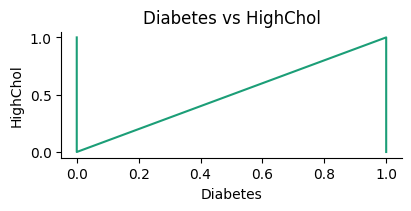

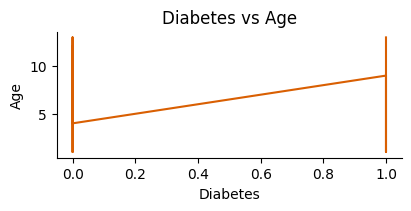

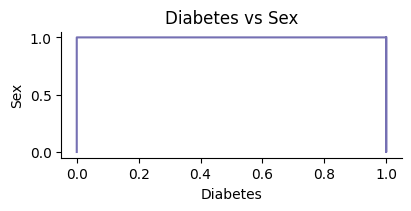

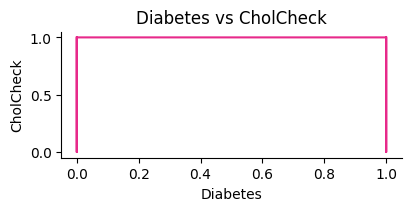

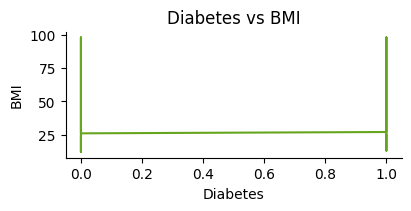

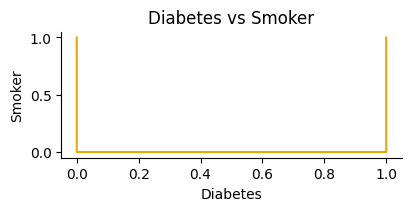

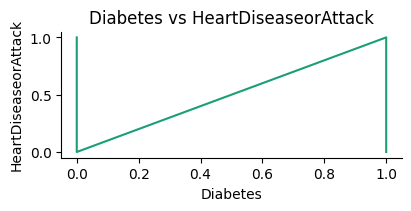

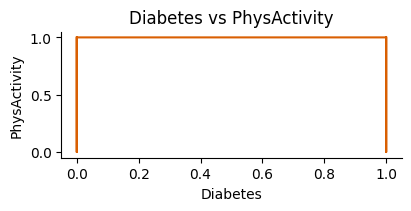

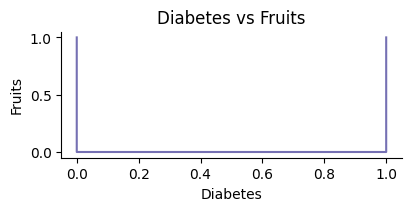

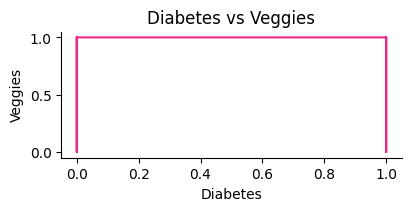

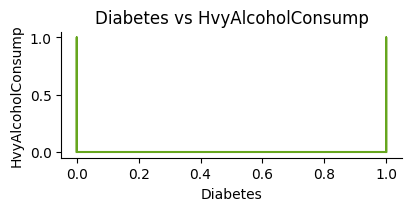

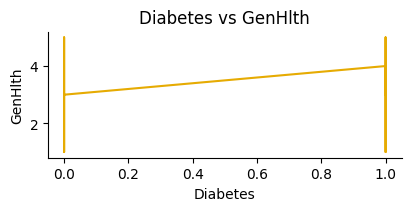

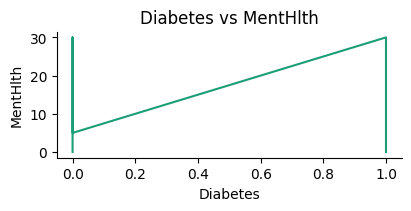

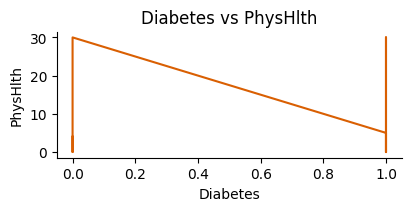

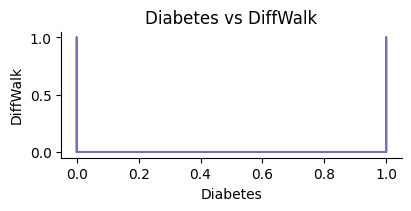

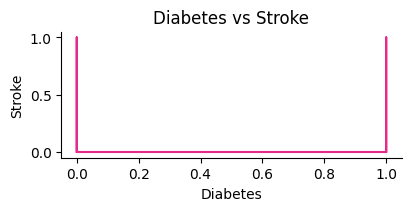

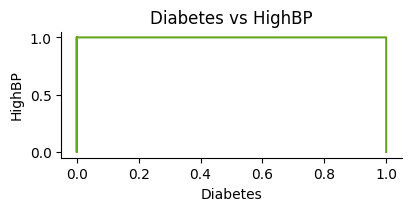

In [7]:

def plot_diabetes_relation(dataset, y_columns):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    df_sorted = dataset.sort_values('Diabetes', ascending=True)

    for i, col in enumerate(y_columns):
        fig, ax = plt.subplots(figsize=(4,2), layout='constrained')
        plt.plot(df_sorted['Diabetes'], df_sorted[col], label=col, color=palette[i % len(palette)])
        sns.despine(fig=fig, ax=ax)
        plt.xlabel('Diabetes')
        plt.ylabel(col)
        plt.title(f'Diabetes vs {col}')
        plt.show()

cols_to_plot = [
    'HighChol', 'Age', 'Sex', 'CholCheck', 'BMI', 'Smoker',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth',
    'DiffWalk', 'Stroke', 'HighBP'
]

plot_diabetes_relation(dataset, cols_to_plot)


## Value counts with response to Target column

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


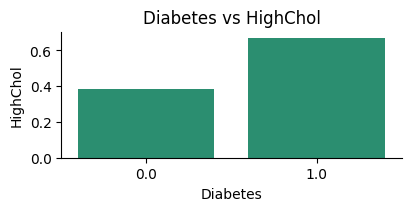

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


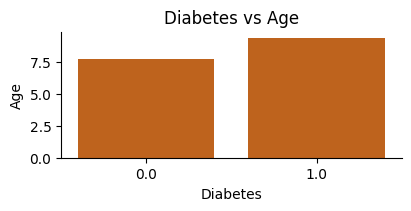

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


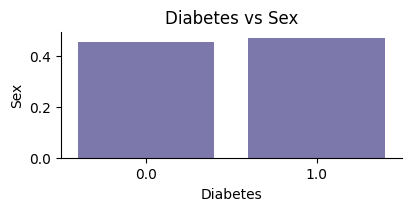

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


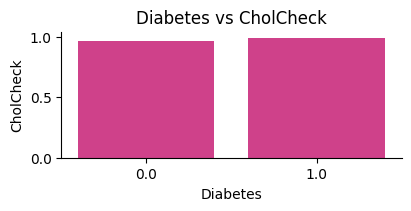

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


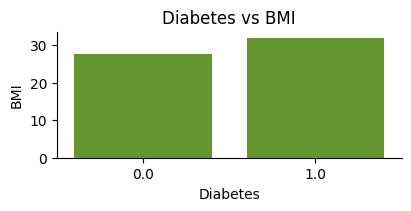

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


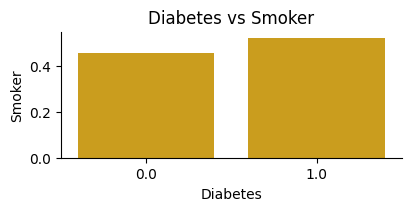

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


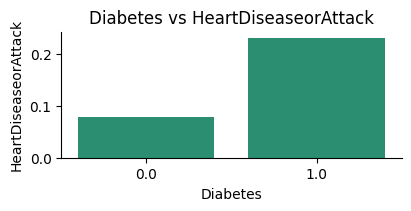

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


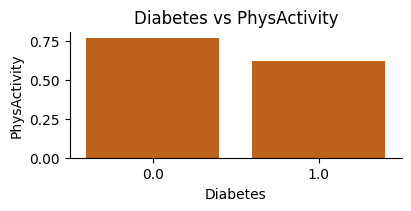

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


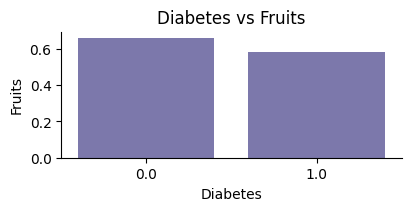

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


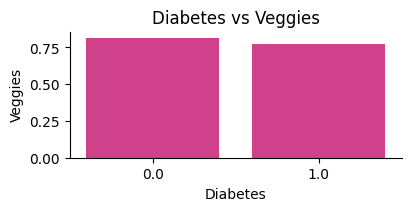

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


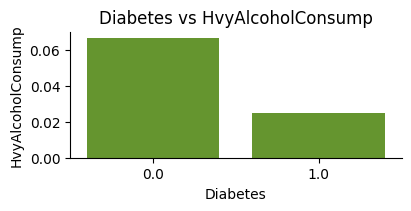

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


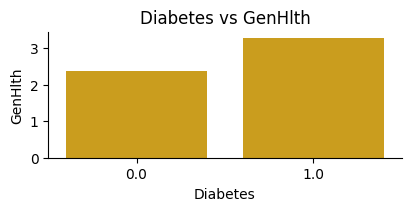

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


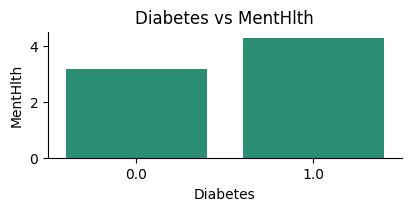

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


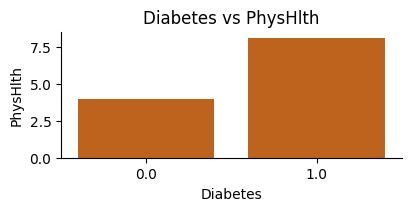

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


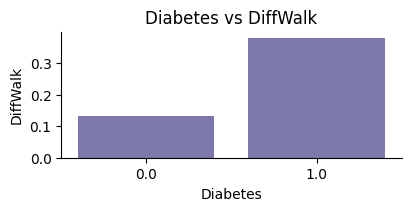

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


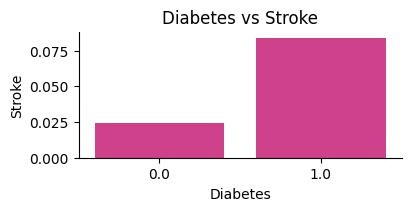

/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_1312/3946483580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


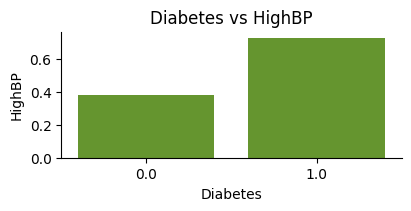

In [8]:

def plot_diabetes_relation(dataset, y_columns):
    palette = list(sns.palettes.mpl_palette('Dark2'))

    for i, col in enumerate(y_columns):
        fig, ax = plt.subplots(figsize=(4, 2), layout='constrained')
        sns.barplot(
            data=dataset,
            x='Diabetes',
            y=col,
            ax=ax,
            palette=[palette[i % len(palette)]] * 2,
            ci=None  # No confidence interval bars
        )
        sns.despine(fig=fig, ax=ax)
        ax.set_xlabel('Diabetes')
        ax.set_ylabel(col)
        ax.set_title(f'Diabetes vs {col}')
        plt.show()

cols_to_plot = [
    'HighChol', 'Age', 'Sex', 'CholCheck', 'BMI', 'Smoker',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth',
    'DiffWalk', 'Stroke', 'HighBP'
]

plot_diabetes_relation(sampled_dataset , cols_to_plot)


## Important Features from the bar charts:
# HighBP,Stroke,DiffWalk,PhyHlth,MenHlth,GenHlth,HvyAlchoholConsump,PhysActivity,HeartDiseaseorAttack,age

In [12]:
# Experiment 1

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [13]:
# Experiment 2


X = dataset[['HeartDiseaseorAttack', 'HvyAlcoholConsump', 'PhysHlth', 'DiffWalk', 'Stroke', 'HighBP']].values
y = dataset.iloc[:, -1].values

In [14]:
# Experiment 3

X = sampled_dataset[['Age','BMI','Fruits','HighChol','Smoker','GenHlth','MentHlth','HeartDiseaseorAttack', 'HvyAlcoholConsump', 'PhysHlth', 'DiffWalk', 'Stroke', 'HighBP']].values
y = sampled_dataset.iloc[:, -1].values

In [15]:
X.shape

(2000, 13)

## Boxplot plotting

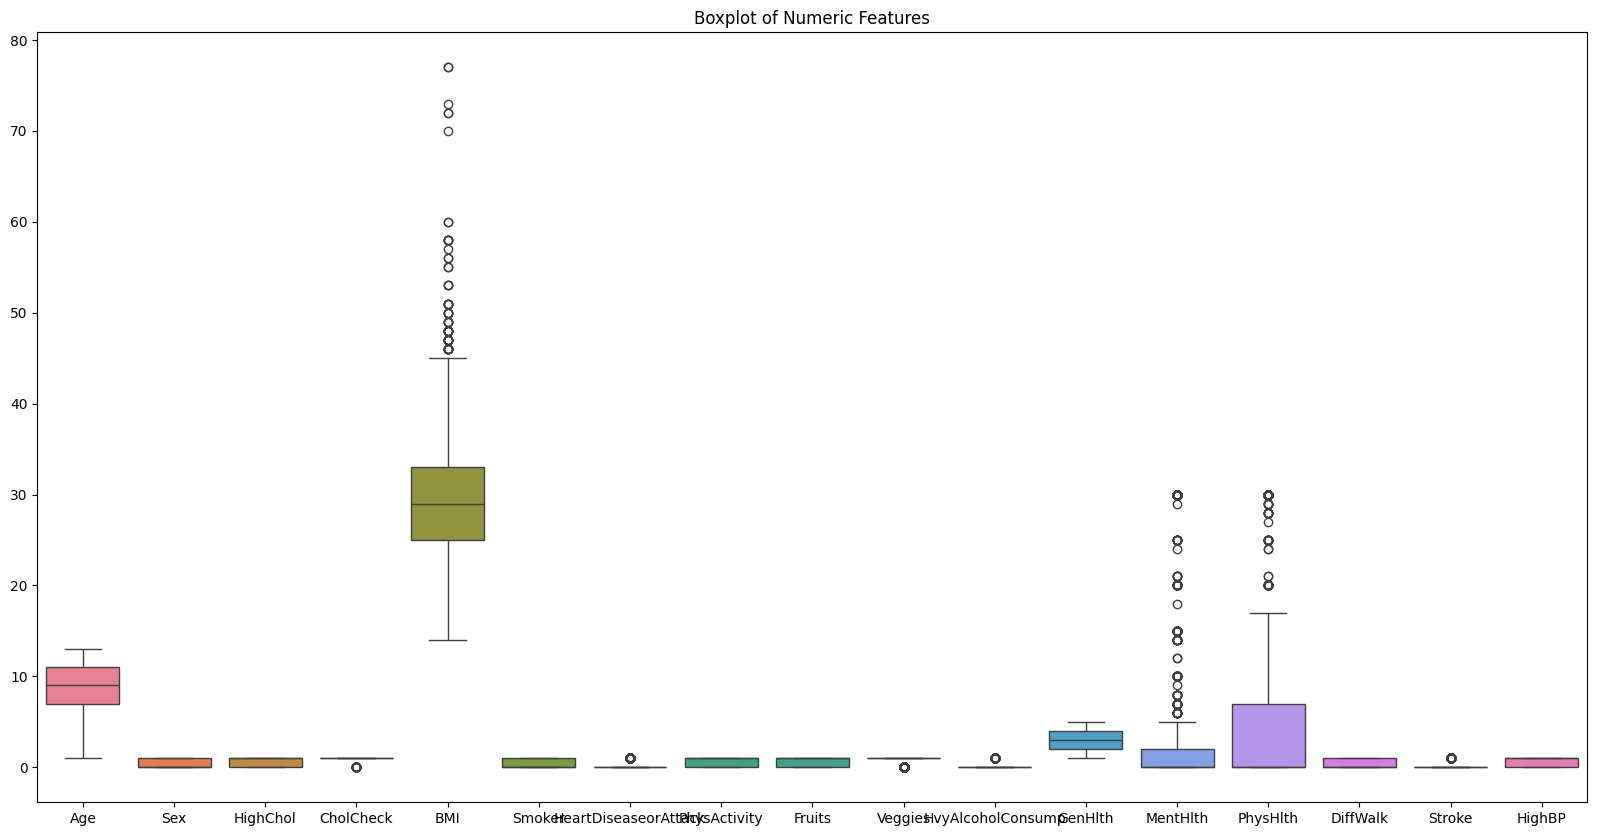

In [16]:
numeric_features = ["Age",	"Sex",	"HighChol",	"CholCheck",	"BMI",	"Smoker",	"HeartDiseaseorAttack",	"PhysActivity",	"Fruits",	"Veggies",	"HvyAlcoholConsump",	"GenHlth",	"MentHlth",	"PhysHlth",	"DiffWalk",	"Stroke",	"HighBP"]

plt.figure(figsize=(20, 10))
sns.boxplot(data=sampled_dataset[numeric_features])
plt.title('Boxplot of Numeric Features')
plt.show()


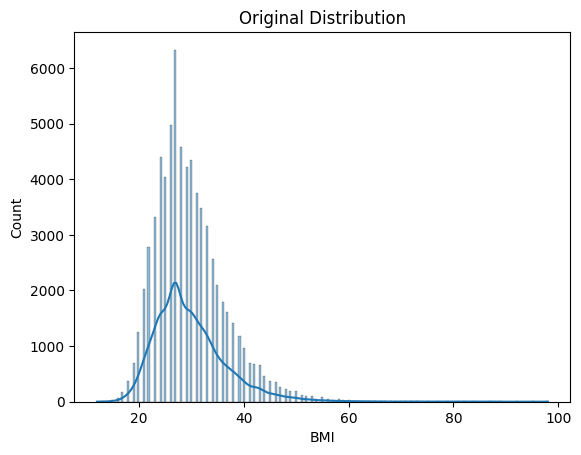

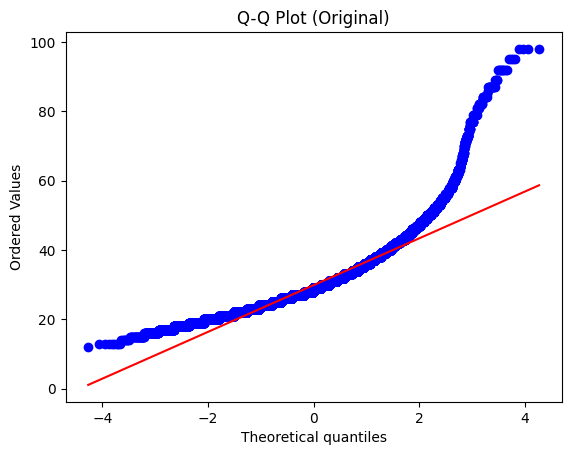

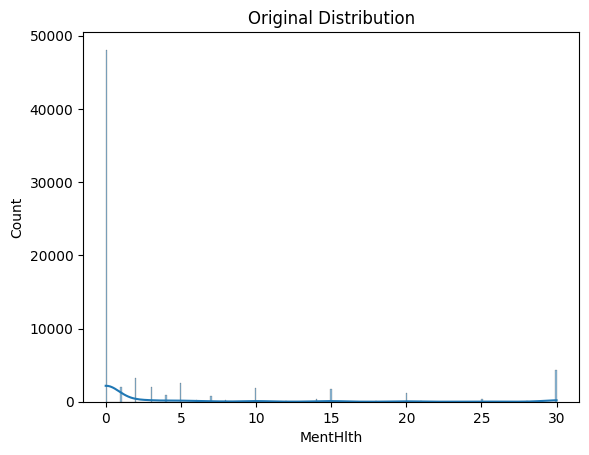

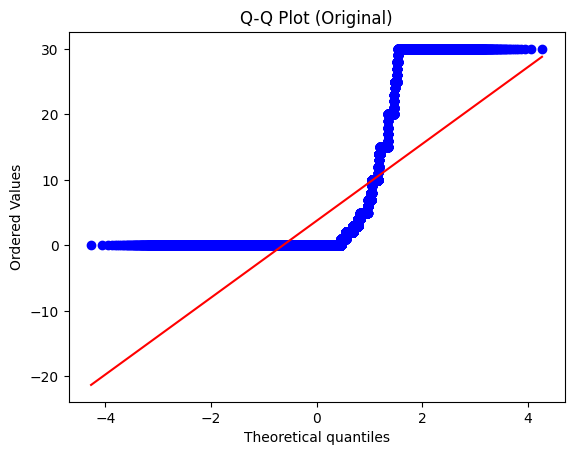

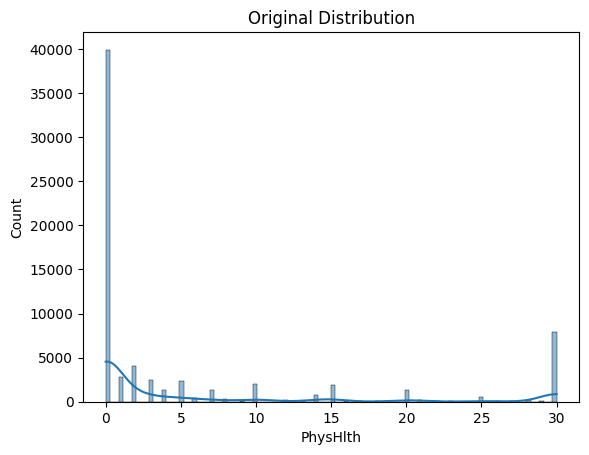

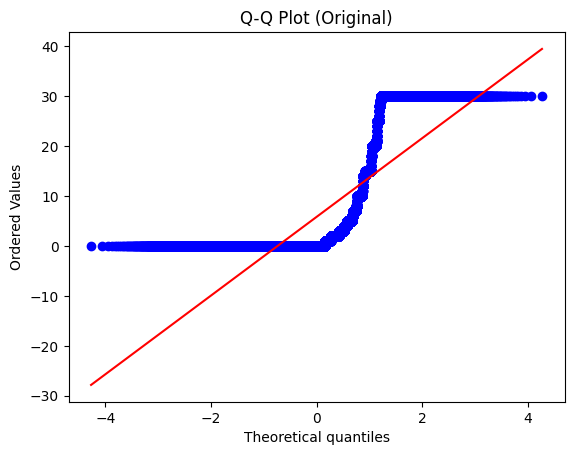

In [17]:
import scipy.stats as stats

# Histogram
sns.histplot(dataset['BMI'], kde=True)
plt.title("Original Distribution")
plt.show()

# Q-Q plot
stats.probplot(dataset['BMI'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Original)")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Histogram
sns.histplot(dataset['MentHlth'], kde=True)
plt.title("Original Distribution")
plt.show()

# Q-Q plot
stats.probplot(dataset['MentHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Original)")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Histogram
sns.histplot(dataset['PhysHlth'], kde=True)
plt.title("Original Distribution")
plt.show()

# Q-Q plot
stats.probplot(dataset['PhysHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Original)")
plt.show()

## Check if any negative value is present

In [18]:
for column in dataset.columns:
    if (dataset[column] < 0).any():
        print(f"Column '{column}' contains negative values.")
    else:
        print(f"Column '{column}' does not contain negative values.")

Column 'Age' does not contain negative values.
Column 'Sex' does not contain negative values.
Column 'HighChol' does not contain negative values.
Column 'CholCheck' does not contain negative values.
Column 'BMI' does not contain negative values.
Column 'Smoker' does not contain negative values.
Column 'HeartDiseaseorAttack' does not contain negative values.
Column 'PhysActivity' does not contain negative values.
Column 'Fruits' does not contain negative values.
Column 'Veggies' does not contain negative values.
Column 'HvyAlcoholConsump' does not contain negative values.
Column 'GenHlth' does not contain negative values.
Column 'MentHlth' does not contain negative values.
Column 'PhysHlth' does not contain negative values.
Column 'DiffWalk' does not contain negative values.
Column 'Stroke' does not contain negative values.
Column 'HighBP' does not contain negative values.
Column 'Diabetes' does not contain negative values.


## log transform the bmi,MentHlth and PhysHlth feature

In [20]:
for col in ['BMI', 'MentHlth', 'PhysHlth']:
    if (sampled_dataset[col] <= 0).any():
        print(f"Warning: Column '{col}' contains non-positive values. Using log1p (log(1+x)).")
        sampled_dataset[col + '_log'] = np.log1p(sampled_dataset[col])
    else:
        sampled_dataset[col + '_log'] = np.log(sampled_dataset[col])


original_cols = ['BMI', 'MentHlth', 'PhysHlth']
log_transformed_cols = [col + '_log' for col in original_cols]

current_X_cols = ['Age','BMI','Fruits','HighChol','Smoker','GenHlth','MentHlth','HeartDiseaseorAttack', 'HvyAlcoholConsump', 'PhysHlth', 'DiffWalk', 'Stroke', 'HighBP']

new_X_cols = [col for col in current_X_cols if col not in original_cols] + log_transformed_cols

X = sampled_dataset[new_X_cols].values

print("X after log transformation:")
print(X[:5])
print("\nUpdated columns in X:", new_X_cols)

X after log transformation:
[[7.         1.         1.         1.         2.         0.
  0.         1.         0.         0.         3.29583687 0.
  0.        ]
 [2.         0.         0.         1.         3.         0.
  0.         0.         0.         0.         3.49650756 0.
  0.        ]
 [9.         1.         1.         0.         3.         0.
  0.         1.         0.         1.         3.55534806 3.4339872
  1.79175947]
 [9.         0.         1.         0.         5.         1.
  0.         0.         0.         1.         3.25809654 3.4339872
  2.77258872]
 [9.         0.         1.         1.         3.         0.
  0.         0.         0.         1.         3.25809654 1.60943791
  0.        ]]

Updated columns in X: ['Age', 'Fruits', 'HighChol', 'Smoker', 'GenHlth', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'DiffWalk', 'Stroke', 'HighBP', 'BMI_log', 'MentHlth_log', 'PhysHlth_log']


## Plotting graphs with Log Transform

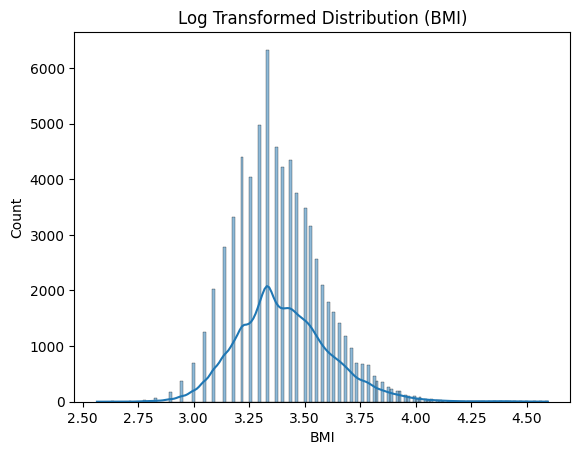

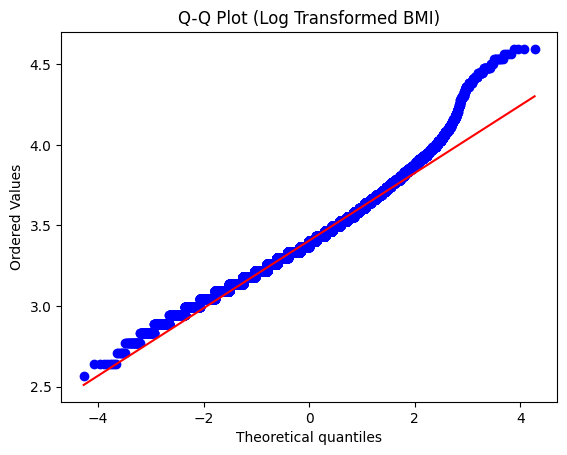

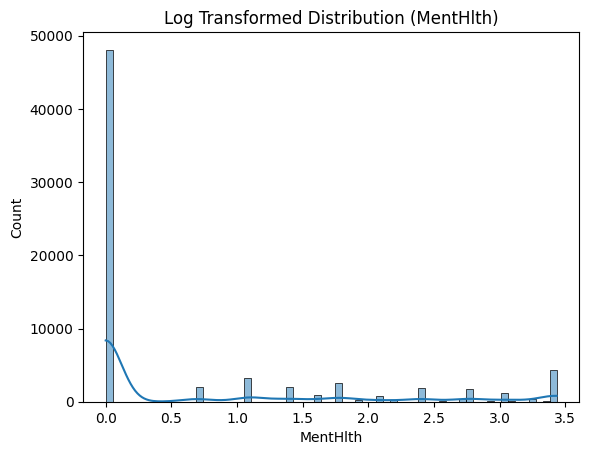

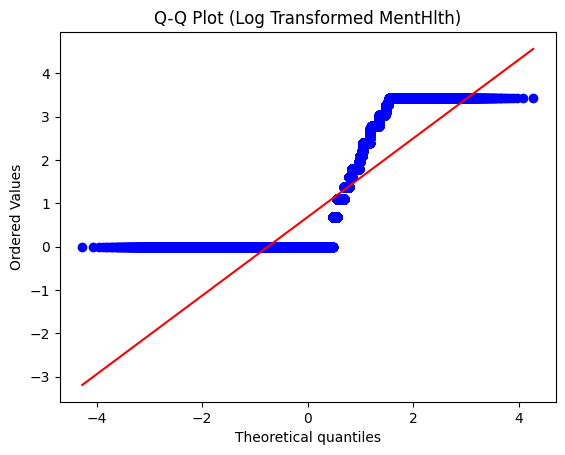

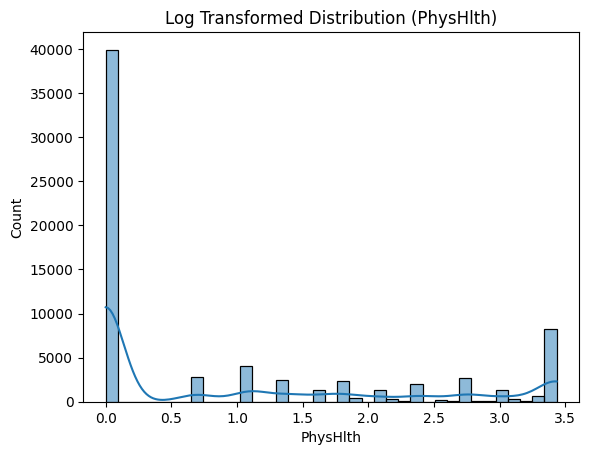

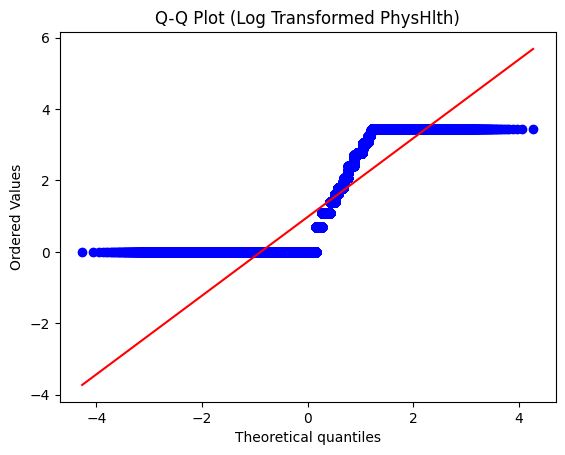

In [21]:
for col in ['BMI', 'MentHlth', 'PhysHlth']:
  dataset[col] = np.log1p(dataset[col])


# Histogram
sns.histplot(dataset['BMI'], kde=True)
plt.title("Log Transformed Distribution (BMI)")
plt.show()

# Q-Q plot
stats.probplot(dataset['BMI'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed BMI)")
plt.show()

# Histogram
sns.histplot(dataset['MentHlth'], kde=True)
plt.title("Log Transformed Distribution (MentHlth)")
plt.show()

# Q-Q plot
stats.probplot(dataset['MentHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed MentHlth)")
plt.show()

# Histogram
sns.histplot(dataset['PhysHlth'], kde=True)
plt.title("Log Transformed Distribution (PhysHlth)")
plt.show()

# Q-Q plot
stats.probplot(dataset['PhysHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed PhysHlth)")
plt.show()

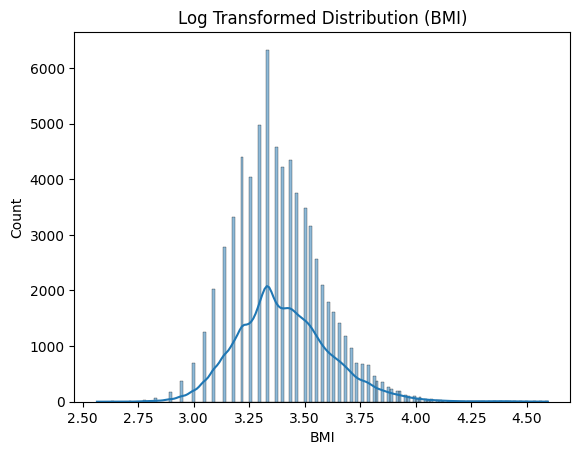

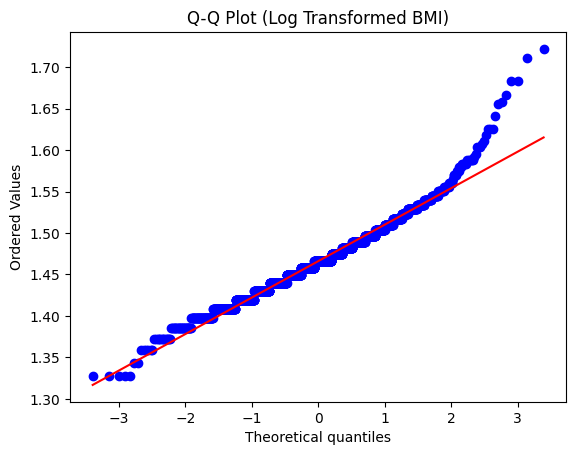

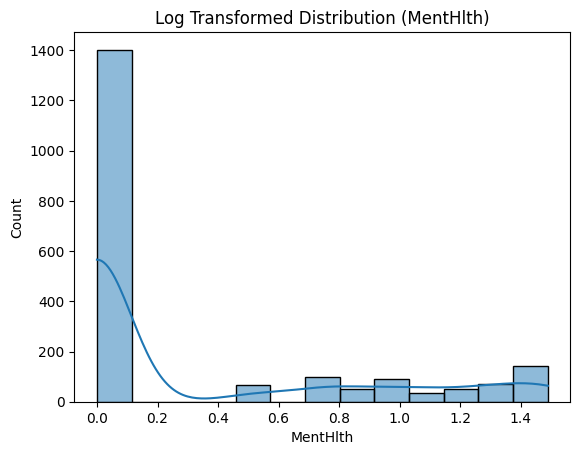

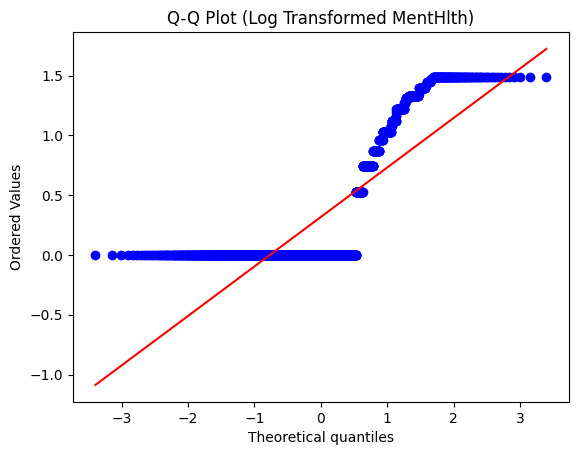

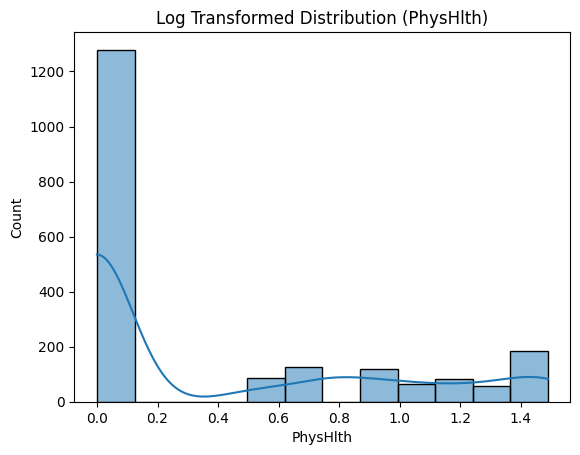

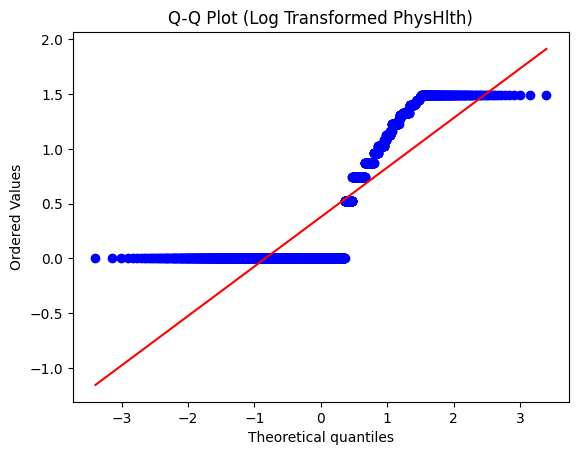

In [22]:

# Apply log transformation to the specified columns
for col in ['BMI', 'MentHlth', 'PhysHlth']:
  # Add a small constant to handle potential zero values before log transformation
  sampled_dataset[col] = np.log1p(dataset[col])

# Verify the transformation by plotting the distributions again

# Histogram
sns.histplot(dataset['BMI'], kde=True)
plt.title("Log Transformed Distribution (BMI)")
plt.show()

# Q-Q plot
stats.probplot(sampled_dataset['BMI'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed BMI)")
plt.show()

# Histogram
sns.histplot(sampled_dataset['MentHlth'], kde=True)
plt.title("Log Transformed Distribution (MentHlth)")
plt.show()

# Q-Q plot
stats.probplot(sampled_dataset['MentHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed MentHlth)")
plt.show()

# Histogram
sns.histplot(sampled_dataset['PhysHlth'], kde=True)
plt.title("Log Transformed Distribution (PhysHlth)")
plt.show()

# Q-Q plot
stats.probplot(sampled_dataset['PhysHlth'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed PhysHlth)")
plt.show()

## Check  outliers

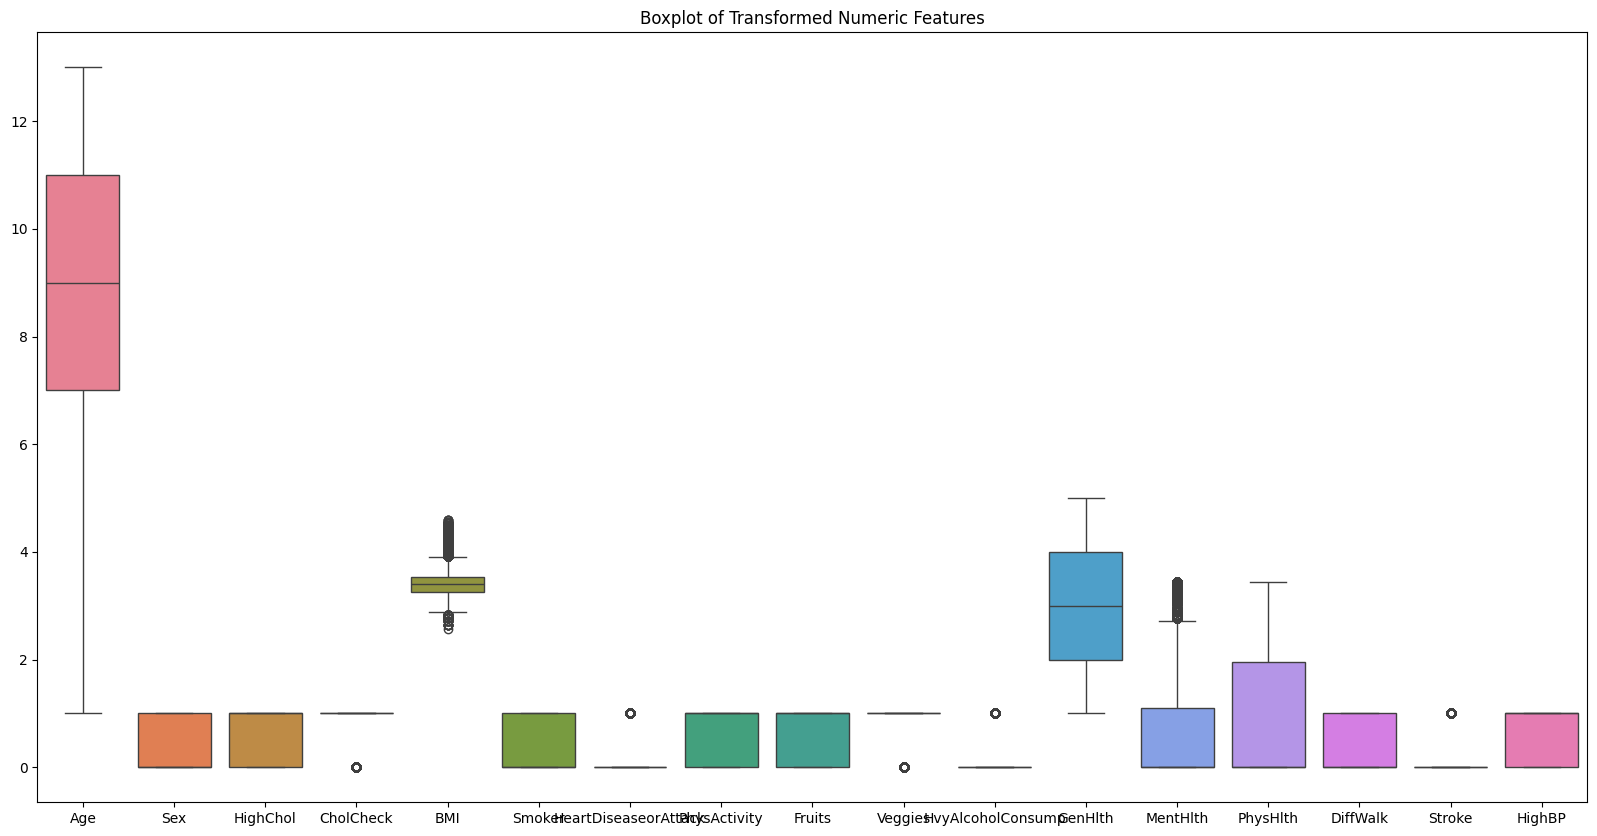

In [23]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=dataset[numeric_features])
plt.title('Boxplot of Transformed Numeric Features')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [25]:
X_train

array([[ 7.        ,  1.        ,  1.        , ...,  3.29583687,
         0.        ,  0.        ],
       [ 7.        ,  1.        ,  1.        , ...,  3.52636052,
         0.        ,  0.        ],
       [11.        ,  1.        ,  1.        , ...,  3.52636052,
         0.        ,  0.        ],
       ...,
       [ 7.        ,  0.        ,  0.        , ...,  3.49650756,
         0.        ,  0.        ],
       [ 8.        ,  0.        ,  0.        , ...,  3.21887582,
         1.09861229,  0.        ],
       [13.        ,  1.        ,  1.        , ...,  3.61091791,
         0.        ,  0.        ]])

## Scaling

In [26]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
rb_scaler = RobustScaler()


robust_scale_cols = ['BMI_log', 'MentHlth_log']
standard_scale_cols = ['Age', 'GenHlth', 'PhysHlth_log']

current_X_cols = new_X_cols

robust_scale_indices = [current_X_cols.index(col) for col in robust_scale_cols]
standard_scale_indices = [current_X_cols.index(col) for col in standard_scale_cols]


X_train[:, robust_scale_indices] = rb_scaler.fit_transform(X_train[:, robust_scale_indices])
X_test[:, robust_scale_indices] = rb_scaler.transform(X_test[:, robust_scale_indices])

sc_scaler = StandardScaler()

X_train[:, standard_scale_indices] = sc_scaler.fit_transform(X_train[:, standard_scale_indices])
X_test[:, standard_scale_indices] = sc_scaler.transform(X_test[:, standard_scale_indices])

print("X_train after scaling:")
print(X_train[:5])
print("\nX_test after scaling:")
print(X_test[:5])


X_train after scaling:
[[-0.53959195  1.          1.          1.         -0.74410745  0.
   0.          1.          0.          0.         -0.25738759  0.
  -0.78222689]
 [-0.53959195  1.          1.          1.         -0.74410745  0.
   0.          0.          0.          1.          0.57293412  0.
  -0.78222689]
 [ 0.87457204  1.          1.          0.          1.03685279  0.
   0.          1.          0.          1.          0.57293412  0.
  -0.78222689]
 [-2.30729693  1.          0.          0.         -0.74410745  0.
   0.          0.          0.          0.         -0.39332424  0.
   0.27489983]
 [-0.53959195  1.          0.          1.          1.92733291  0.
   0.          1.          1.          1.         -0.68162956  0.
   1.83637974]]

X_test after scaling:
[[-2.66083792  0.          0.          0.         -1.63458757  0.
   0.          0.          0.          0.         -0.39332424  0.63092975
  -0.78222689]
 [-0.53959195  0.          1.          1.          1.92733291  

## PCA Plotting

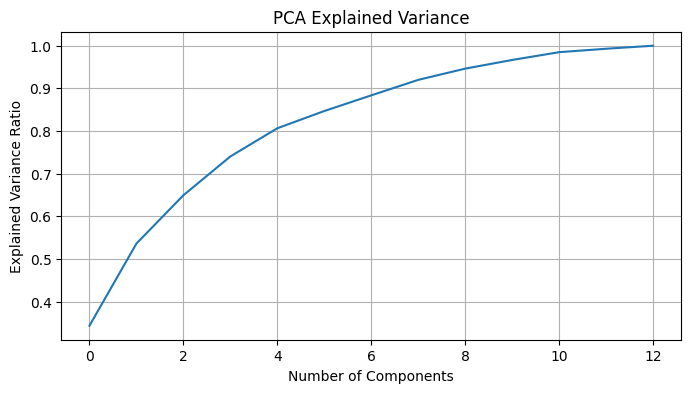


Original X_train shape: (1600, 13)
Transformed X_train_pca shape: (1600, 5)
Transformed X_test_pca shape: (400, 5)


In [27]:
from sklearn.decomposition import PCA


pca = PCA(n_components=None)
pca.fit(X_train)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()


n_components_chosen = 5
pca = PCA(n_components=n_components_chosen)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Transformed X_train_pca shape: {X_train_pca.shape}")
print(f"Transformed X_test_pca shape: {X_test_pca.shape}")



In [ ]:
X_train.shape

(1600, 13)

## Applying GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.5,0.1, 1, 10,100],
    'gamma': ['scale', 1,0.1,0.01,0.001,0.001],
    'degree': [2, 3, 4]  # for poly
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.5,0.1, 1, 10,100],
    'gamma': ['scale', 1,0.1,0.01,0.001,0.001],
    'degree': [2, 3, 4]  # for poly
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)


KeyboardInterrupt: 

In [33]:

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

# Initialize the SVM classifier with the best parameters found by GridSearchCV
classifier = SVC(C=1, degree=2, gamma='scale', kernel='rbf', random_state=0)

# Train the classifier on the training data
classifier.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy}")



Confusion Matrix:
[[144  59]
 [ 48 149]]

Accuracy: 0.7325


Accuracy: 0.7325
Precision: 0.7163
Recall: 0.7563
F1-score: 0.7358
Confusion Matrix:
[[144  59]
 [ 48 149]]


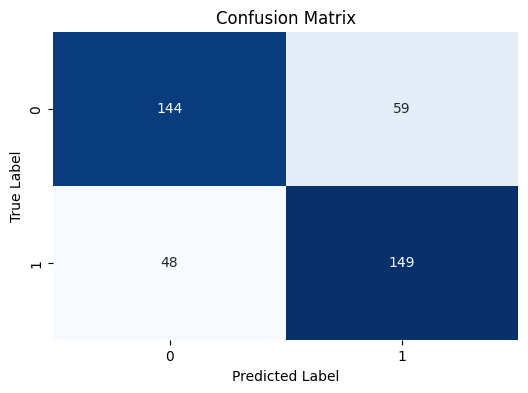

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train the SVM model
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)

# Optional: Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [31]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Predictions on the test set:")
print(y_pred)

Predictions on the test set:
[0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1.
 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1.
 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1.
 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0.
 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1.
 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1.
 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0.
 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1.
 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1.
 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1.
 0. 0. 1. 1. 0. 0. 0. 